In [1]:
import tethys # tethys is installed from the `improve_temporal_rebase` branch
import xarray as xr
import rioxarray as rio
import cartopy as ct
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
config_path = './test_config.yml'

In [3]:
results = tethys.Tethys(config_file=config_path)

In [4]:
results.run_model()

Loading Proxy Data
Interpolating Proxies
Database scenarios: rcp45cooler_ssp3
Downscaling Domestic
Downscaling Electricity


/Users/thur961/im3/tethys_integration_metarepo/venv/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


Database scenarios: rcp45cooler_ssp3
Downscaling Irrigation


/Users/thur961/im3/tethys_integration_metarepo/venv/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 20
  result = blockwise(


Downscaling Livestock
Downscaling Manufacturing
Downscaling Mining


In [5]:
results.outputs

<xarray.Dataset> Size: 6GB
Dimensions:                      (year: 46, lat: 224, lon: 464, month: 12)
Coordinates:
  * lat                          (lat) float64 2kB 52.94 52.81 ... 25.19 25.06
  * lon                          (lon) float64 4kB -124.9 -124.8 ... -67.06
    spatial_ref                  int64 8B ...
  * year                         (year) int64 368B 1975 1976 1977 ... 2019 2020
  * month                        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/26)
    Domestic                     (year, lat, lon, month) float32 229MB 0.0 .....
    electricity_biomass          (year, lat, lon, month) float32 229MB 0.0 .....
    electricity_coal             (year, lat, lon, month) float32 229MB 0.0 .....
    electricity_gas              (year, lat, lon, month) float32 229MB 0.0 .....
    electricity_geothermal       (year, lat, lon, month) float32 229MB 0.0 .....
    electricity_nuclear          (year, lat, lon, month) float32 229MB 0.0 .....
    ...                           ...
    Dairy                        (year, lat, lon, month) float32 229MB 0.0 .....
    Pork                         (year, lat, lon, month) float32 229MB 0.0 .....
    Poultry                      (year, lat, lon, month) float32 229MB 0.0 .....
    SheepGoat                    (year, lat, lon, month) float32 229MB 0.0 .....
    Manufacturing                (year, lat, lon, month) float32 229MB 0.0 .....
    Mining                       (year, lat, lon, month) float32 229MB 0.0 .....

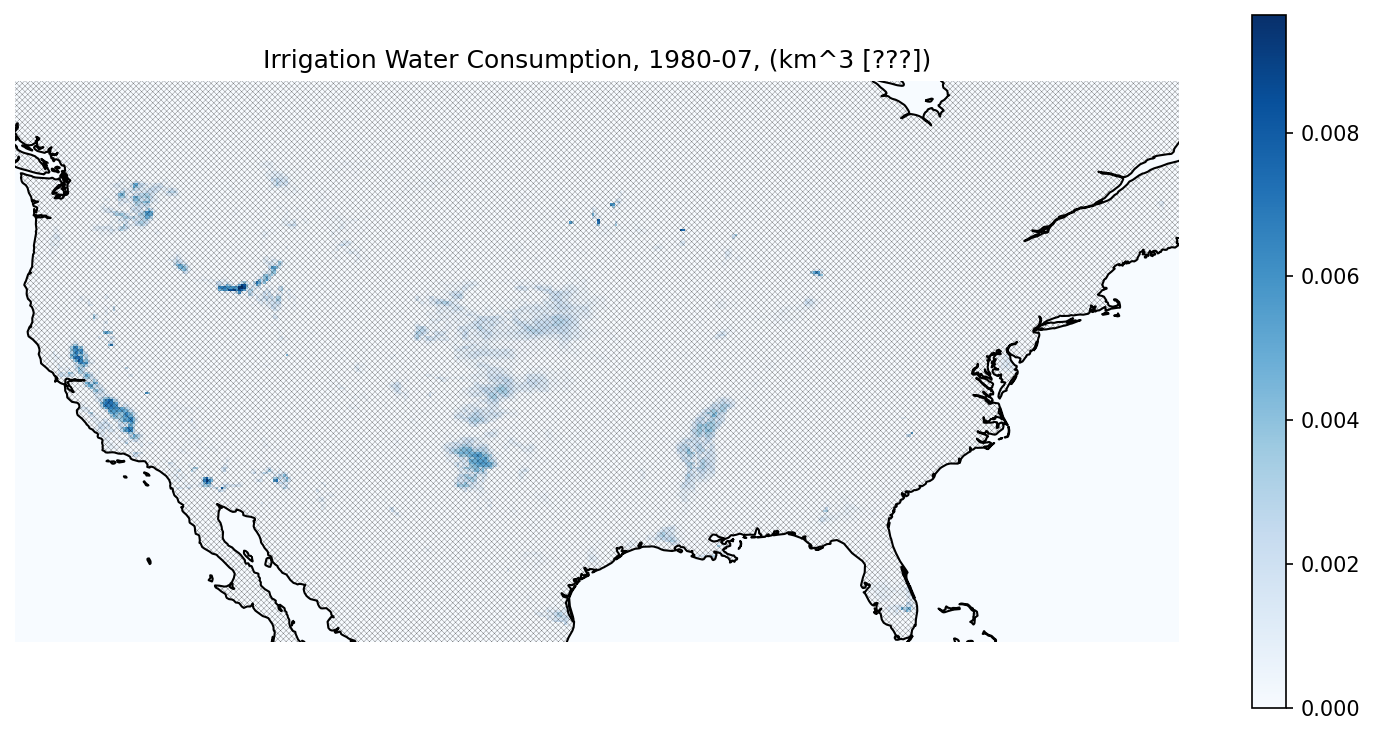

In [7]:
crs = ct.crs.PlateCarree()
fig = plt.figure(figsize=(10, 5), dpi=150, layout='tight')
ax = plt.axes(projection=crs, frameon=False)
plt.rcParams['hatch.linewidth'] = 0.1
ax.coastlines(hatch='xxxxxxxxx')

results.outputs[[
    'Corn', 'FiberCrop', 'MiscCrop', 'OilCrop', 'OtherGrain',
    'Rice', 'RootTuber', 'biomass', 'FodderHerb',
    'SugarCrop', 'Wheat',
]].sel(year=1980, month=7).to_array().sum(dim='variable').plot(
    ax=ax,
    cmap='Blues',
)
ax.set_title('Irrigation Water Consumption, 1980-07, (km^3 [???])');